# House Price Prediction using XGBoost

## Objective
The goal of this project is to predict house prices based on housing features such as:

- crime rate
- number of rooms
- accessibility to highways
- tax rate
- socioeconomic indicators

We use XGBoost Regressor, a powerful gradient boosting algorithm, to improve prediction accuracy.

**Importing the dependencies**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

**Loading the dataset**

In [2]:
column_names = ["CRIM", "ZN" , "INDUS" ,"CHAS", "NOX", "RM" , "AGE", "DIS","RAD","TAX","PTRATIO","B","LSTAT","PRICE"]
house_price_dataset = pd.read_csv("data/housing.csv",header=None,sep=r"\s+",names=column_names)

In [3]:
print(house_price_dataset)

        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0    0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1    0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2    0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3    0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4    0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...    ...   
501  0.06263   0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273.0   
502  0.04527   0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273.0   
503  0.06076   0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273.0   
504  0.10959   0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273.0   
505  0.04741   0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273.0   

     PTRATIO       B  LSTAT  PRICE  
0       15.3  396.90   4.98   24.0  
1       17.8  396.90   9.

In [4]:
house_price_dataset.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## Dataset Description

Dataset contains 14 features describing housing conditions.

Important features:

RM → average number of rooms  
LSTAT → percentage of lower income population  
PTRATIO → pupil-teacher ratio  
CRIM → crime rate  
PRICE → median house value (target)

In [5]:
# checking the number of rows and columns in the data frame
house_price_dataset.shape

(506, 14)

## Data Overview

We inspect dataset structure, number of samples, and feature types.

In [6]:
# checking the dataset for missing values
house_price_dataset.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [7]:
# statistical measures of the dataset
house_price_dataset.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## Feature Relationships

Correlation heatmap helps identify features strongly related to house price.

**Understanidng the correlation between various feature in the dataset**

1. Positive Correlation

2. Negative Correlation

In [8]:
correlation = house_price_dataset.corr()

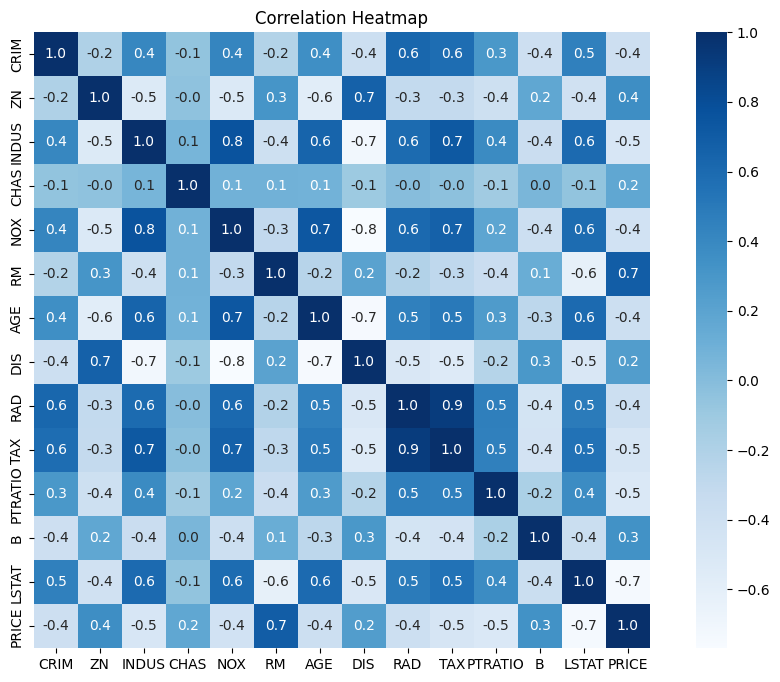

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(correlation, cbar=True, square = True, fmt='.1f', annot=True, annot_kws={'size':10}, cmap='Blues')

plt.title("Correlation Heatmap")

plt.show()

## Splitting Features and Target

X contains input features  
y contains house price (PRICE)

In [10]:
X = house_price_dataset.drop(["PRICE"],axis = 1)
Y = house_price_dataset['PRICE']

In [11]:
print(X)
print(Y)

        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0    0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1    0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2    0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3    0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4    0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...    ...   
501  0.06263   0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273.0   
502  0.04527   0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273.0   
503  0.06076   0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273.0   
504  0.10959   0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273.0   
505  0.04741   0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273.0   

     PTRATIO       B  LSTAT  
0       15.3  396.90   4.98  
1       17.8  396.90   9.14  
2       1

## Train Test Split

Dataset divided into:

Training set → model learns patterns  
Testing set → evaluate performance

In [12]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [13]:
print(X.shape,X_train.shape,X_test.shape)

(506, 13) (404, 13) (102, 13)


## Model: XGBoost Regressor

XGBoost is an advanced gradient boosting algorithm that builds multiple decision trees sequentially.

Advantages:
- handles non-linear relationships
- reduces overfitting
- high prediction accuracy
- widely used in machine learning competitions

In [14]:
# loading the model
model = XGBRegressor()

In [15]:
# training the model with X_train
model.fit(X_train,Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Prediction on training data

In [16]:
# accuracy for prediction on the training data
training_data_prediction = model.predict(X_train)

In [17]:
print(training_data_prediction)

[11.990929  19.915493  19.392988  13.408072  18.19098   24.603947
 21.08647   24.697266   8.70618   27.501347  20.708258  36.17404
 31.59529   11.69739   39.802494  13.893334  21.796898  23.695662
 17.590319  24.409176   8.799549  19.181791  25.278059  20.410582
 23.10783   37.90089   15.601625  45.400623  15.706774  22.599428
 14.514692  18.697655  17.797323  16.117708  20.609972  31.598558
 29.095152  15.600668  17.563873  22.51095   19.401443  19.287243
  8.4968405 20.607521  17.006351  17.093975  14.495169  49.98619
 14.284735  12.609954  28.688086  21.203852  19.306932  23.089056
 19.10372   25.004898  33.408142   4.992768  29.599434  18.685545
 21.707012  23.096918  22.802471  20.991085  48.796387  14.627051
 16.613852  27.075224  20.087227  19.794464  20.992268  41.290615
 23.175125  20.378569  18.558722  29.399414  36.40198   24.388987
 11.816533  13.792832  12.272116  17.794773  33.087368  26.73878
 13.393904  14.386449  50.004574  21.98985   19.906004  23.784376
 17.516703  1

## Model Evaluation

We evaluate model performance using:

MAE → average prediction error  
MSE → squared error  
R² → goodness of fit

In [18]:
# R squared error
score_1 = metrics.r2_score(Y_train,training_data_prediction)

# Mean absolute error
score_2 = metrics.mean_absolute_error(Y_train,training_data_prediction)

print(f"R squared error : {(score_1)}%")
print(f"Mean absolute error : {(score_2)}%")

R squared error : 0.9999969829984965%
Mean absolute error : 0.011182523717974735%


# **Visualising the actual Prices and the predicted prices**

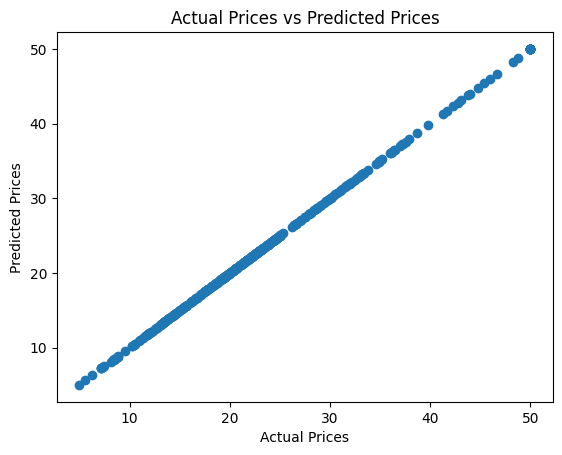

In [19]:
plt.scatter(Y_train,training_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

In [20]:
importance = model.feature_importances_

feature_names = X.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(10)

,Feature,Importance
5,RM,0.403303
12,LSTAT,0.325284
7,DIS,0.063517
9,TAX,0.046922
0,CRIM,0.036416
10,PTRATIO,0.035251
4,NOX,0.024681
8,RAD,0.021677
6,AGE,0.011992
11,B,0.010269


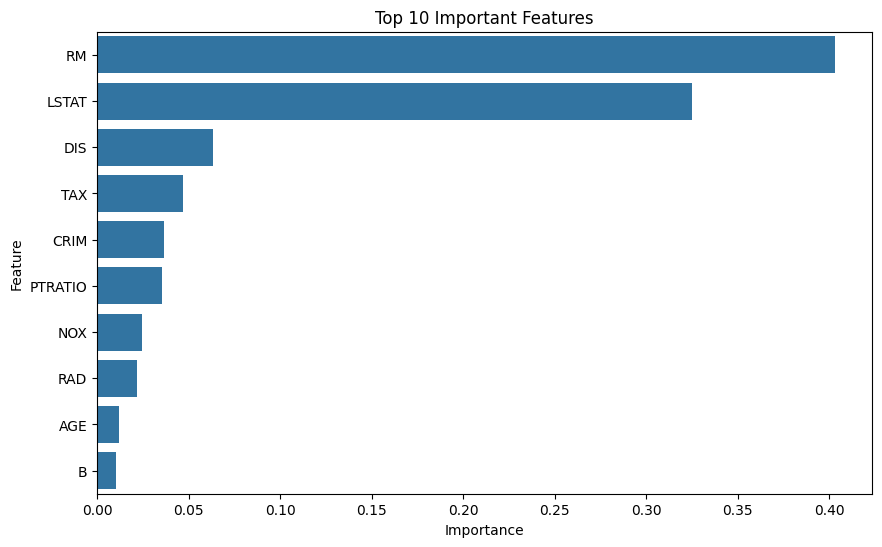

In [21]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

### Feature Importance Insight

The most influential features affecting house price include:

RM (average number of rooms)

LSTAT (percentage of lower income population)

PTRATIO (pupil-teacher ratio)

TAX (property tax rate)

These variables have strong relationships with house value.

In [22]:
# accuracy for prediction on the test data
test_data_prediction = model.predict(X_test)

In [23]:
# Rsqaured error
score_1 = metrics.r2_score(Y_test,test_data_prediction)

# Mean absolute error
score_2 = metrics.mean_absolute_error(Y_test,test_data_prediction)

print(f"R squared error : {(score_1)}%")
print(f"Mean absolute error : {(score_2)}%")

R squared error : 0.9057837838492537%
Mean absolute error : 1.8908873698290656%


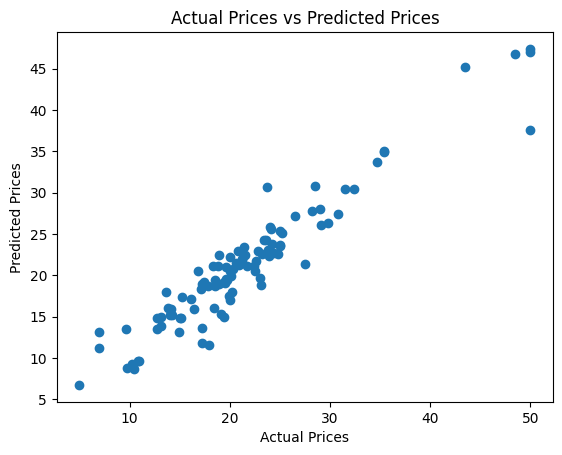

In [24]:
plt.scatter(Y_test,test_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

## Conclusion

The XGBoost Regressor model predicts house prices based on housing features.

Key observations:

number of rooms (RM) strongly influences price

lower socioeconomic status (LSTAT) negatively impacts price

property tax and accessibility features also influence price

XGBoost performs well because it captures non-linear relationships.

Future improvements:

hyperparameter tuning

cross validation

feature scaling

try other ensemble models

collect more data